In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from matplotlib import pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [3]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [4]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 4.00G/4.00G [00:25<00:00, 170MB/s]



In [5]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [6]:
df = pd.read_csv("/content/data/driver_imgs_list.csv")
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [7]:
drivers = df['subject'].unique()
print("Total drivers:", len(drivers))

Total drivers: 26


In [8]:
train_drivers, temp_drivers = train_test_split(
    drivers,
    test_size=0.4,
    random_state=42
)

val_drivers, test_drivers = train_test_split(
    temp_drivers,
    test_size=0.5,
    random_state=42
)

print("Train drivers:", len(train_drivers))
print("Val drivers:", len(val_drivers))
print("Test drivers:", len(test_drivers))

Train drivers: 15
Val drivers: 5
Test drivers: 6


In [9]:
train_df = df[df['subject'].isin(train_drivers)]
val_df = df[df['subject'].isin(val_drivers)]
test_df = df[df['subject'].isin(test_drivers)]

print(train_df['subject'].nunique())
print(val_df['subject'].nunique())
print(test_df['subject'].nunique())

15
5
6


In [10]:
base_path = "/content/data/imgs/train"

def add_image_path(df):
    return df.apply(
        lambda row: os.path.join(base_path, row['classname'], row['img']),
        axis=1
    )

train_paths = add_image_path(train_df)
val_paths = add_image_path(val_df)
test_paths = add_image_path(test_df)

train_labels = train_df['classname']
val_labels = val_df['classname']
test_labels = test_df['classname']

In [11]:
le = LabelEncoder()
train_labels = le.fit_transform(train_labels)
val_labels = le.transform(val_labels)
test_labels = le.transform(test_labels)

In [25]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [26]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
tf.random.set_seed(42)

def process_image_dual(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    # 🔥 Controlled ROI (tight + realistic)
    shift_h = tf.random.uniform([], -0.02, 0.02)
    shift_w = tf.random.uniform([], -0.04, 0.04)

    top = tf.cast((0.45 + shift_h) * tf.cast(h, tf.float32), tf.int32)
    bottom = tf.cast(0.95 * tf.cast(h, tf.float32), tf.int32)
    left = tf.cast((0.30 + shift_w) * tf.cast(w, tf.float32), tf.int32)
    right = tf.cast(0.75 * tf.cast(w, tf.float32), tf.int32)

    roi = image[top:bottom, left:right]

    # Resize
    image = tf.image.resize(image, IMG_SIZE)
    roi   = tf.image.resize(roi, IMG_SIZE)

    image = tf.cast(image, tf.float32)
    roi   = tf.cast(roi, tf.float32)

    return (image, roi), label

def create_dataset_dual(paths, labels, shuffle=True):

    labels = tf.one_hot(labels, depth=10)

    ds = tf.data.Dataset.from_tensor_slices((paths.values, labels))

    if shuffle:
        ds = ds.shuffle(3000)

    ds = ds.map(process_image_dual, num_parallel_calls=tf.data.AUTOTUNE)

    # 🔥 cache for speed
    ds = ds.cache('/tmp/dual_cache')

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    options = tf.data.Options()
    options.experimental_deterministic = False
    ds = ds.with_options(options)

    return ds

train_ds = create_dataset_dual(train_paths, train_labels, True)
val_ds   = create_dataset_dual(val_paths, val_labels, False)
test_ds  = create_dataset_dual(test_paths, test_labels, False)

In [27]:
for path in train_paths[:5]:
    print(path, os.path.exists(path))

/content/data/imgs/train/c0/img_48693.jpg True
/content/data/imgs/train/c0/img_44903.jpg True
/content/data/imgs/train/c0/img_58514.jpg True
/content/data/imgs/train/c0/img_62307.jpg True
/content/data/imgs/train/c0/img_83984.jpg True


In [28]:
set(train_drivers) & set(val_drivers)
set(train_drivers) & set(test_drivers)
set(val_drivers) & set(test_drivers)

set()

In [29]:
for images, labels in train_ds.take(1):
    print("Full Image batch shape:", images[0].shape)
    print("ROI Image batch shape:", images[1].shape)
    print("Label batch shape:", labels.shape)

Full Image batch shape: (32, 224, 224, 3)
ROI Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 10)


In [30]:
print("Train images:", len(train_paths))
print("Val images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 13440
Val images: 3312
Test images: 5672


In [31]:
def dual_mobilenet_style(input_shape=(224,224,3), num_classes=10):

    img_input = tf.keras.Input(shape=input_shape)
    roi_input = tf.keras.Input(shape=input_shape)

    # 🔥 Aug only on full image
    img = data_augmentation(img_input)
    img = tf.keras.layers.Rescaling(1./255)(img)

    roi = tf.keras.layers.Rescaling(1./255)(roi_input)

    # -------- Shared Backbone --------
    def backbone(x):

        x = tf.keras.layers.Conv2D(32, 3, strides=2, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.SeparableConv2D(64, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.SeparableConv2D(128, 3, strides=2, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.SeparableConv2D(128, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        return x

    shared_input = tf.keras.Input(shape=input_shape)
    shared_output = backbone(shared_input)
    shared_model = tf.keras.Model(shared_input, shared_output)

    f_img = shared_model(img)
    f_roi = shared_model(roi)

    # 🔥 Lightweight attention on ROI
    attn = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(f_roi)
    f_roi = tf.keras.layers.Multiply()([f_roi, attn])

    # Fusion
    x = tf.keras.layers.Concatenate()([f_img, f_roi])

    # Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return tf.keras.Model([img_input, roi_input], outputs)

In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    min_delta=1e-3
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])

In [33]:
model = dual_mobilenet_style()
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ sequential_2[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ input_layer_9[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_7        │ (None, 56, 56,    │     31,264 │ rescaling_4[0][0… │
│ (Functional)        │ 128)              │            │ rescaling_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56, 1) │        129 │ functional_7[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 56, 56,    │          0 │ functional_7[1][… │
│ (Multiply)          │ 128)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 56, 56,    │          0 │ functional_7[0][… │
│ (Concatenate)       │ 256)              │            │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ concatenate_2[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │      2,570 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,755 (389.67 KB)

 Trainable params: 99,051 (386.92 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# y_train = np.concatenate([y for x, y in train_ds], axis=0)
# y_train_labels = np.argmax(y_train, axis=1)

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_labels),
#     y=y_train_labels
# )

# class_weights = dict(enumerate(class_weights))

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 229s 474ms/step - accuracy: 0.1369 - loss: 2.2928 - val_accuracy: 0.1049 - val_loss: 2.2968 - learning_rate: 1.0000e-04
Epoch 2/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 77s 182ms/step - accuracy: 0.1956 - loss: 2.2211 - val_accuracy: 0.1517 - val_loss: 2.2518 - learning_rate: 1.0000e-04
Epoch 3/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 71s 169ms/step - accuracy: 0.2705 - loss: 2.1122 - val_accuracy: 0.2097 - val_loss: 2.1414 - learning_rate: 1.0000e-04
Epoch 4/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 71s 170ms/step - accuracy: 0.3511 - loss: 1.9394 - val_accuracy: 0.2867 - val_loss: 2.0080 - learning_rate: 1.0000e-04
Epoch 5/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 71s 168ms/step - accuracy: 0.4102 - loss: 1.7889 - val_accuracy: 0.3290 - val_loss: 1.9077 - learning_rate: 1.0000e-04
Epoch 6/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 75s 178ms/step - accuracy: 0.4577 - loss: 1.6943 - val_accuracy: 0.3630 - val_loss: 1.8622 - learning_rate: 1.0000e-04
Epoch 7/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 71s 1

In [35]:
model.save("/content/data/models/dual_mobilenet_style.keras")

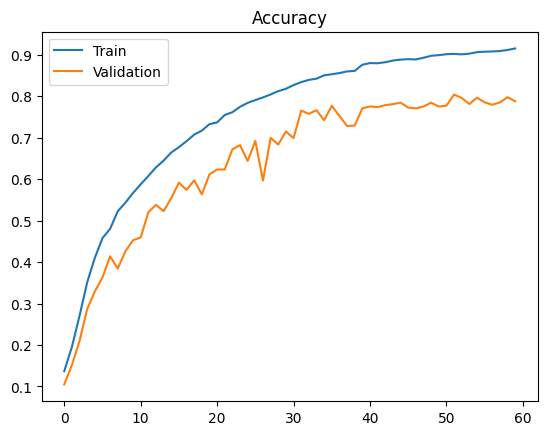

In [36]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

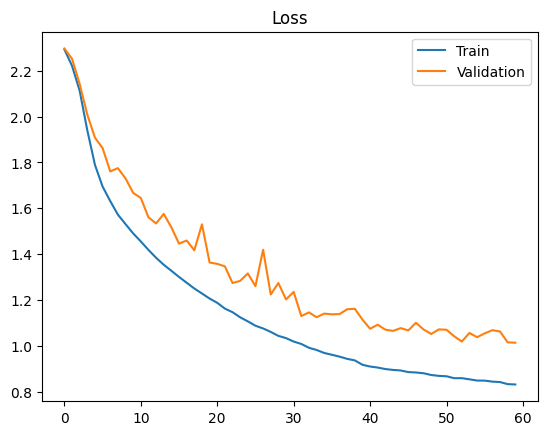

In [37]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [38]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.8116 - loss: 0.9823
Test Accuracy: 0.8116222023963928


In [39]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
Time per image (seconds): 0.36055684089660645


In [40]:
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

Time per image (milliseconds): 360.55684089660645
